# 03. Árvore de Decisão e Random Forest

Neste notebook, construímos e avaliamos dois modelos baseados em árvores de decisão para o problema de **Manutenção Preditiva** (AI4I 2020):

1. **Árvore de Decisão Individual** com poda via *Minimal Cost-Complexity Pruning* e validação cruzada estratificada.
2. **Random Forest** como ensemble de múltiplas árvores que tende a ser mais robusto.

Seguiremos o mesmo rigor do notebook anterior (Rede Neural), incluindo:
- **Validação cruzada estratificada 5-fold** (Regra de Ouro: $K \approx N/5$).
- **F2-Score como métrica prioritária** de seleção de hiperparâmetros, pois em manutenção preditiva o custo de um falso negativo (falha não detectada) é muito maior que o de um falso positivo (alarme falso).
- **Tratamento de desbalanceamento** via `class_weight='balanced'` (testado como hiperparâmetro).


In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, classification_report, confusion_matrix
)

# Configurações de plotagem
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

# Importar pacote local
sys.path.insert(0, os.path.abspath('..'))
from src.arvore_decisao import (
    obter_alphas_candidatos, cross_val_arvore, grid_search_random_forest, f2_scorer
)

SEED = 42
np.random.seed(SEED)

DADOS_TRATADOS = os.path.abspath('../dados_tratados')
MODELOS_DIR = os.path.abspath('../modelos')
os.makedirs(MODELOS_DIR, exist_ok=True)


---
## 1. Carregamento dos Dados

Utilizamos os mesmos conjuntos de treino e teste já preparados no notebook `01_extracao_e_eda.ipynb` e utilizados na Rede Neural. A distribuição do alvo será impressa para conferência.


In [2]:
X_train = pd.read_csv(os.path.join(DADOS_TRATADOS, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(DADOS_TRATADOS, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(DADOS_TRATADOS, 'y_train.csv')).values.ravel()
y_test = pd.read_csv(os.path.join(DADOS_TRATADOS, 'y_test.csv')).values.ravel()

feature_names = list(X_train.columns)
X_train = X_train.values
X_test = X_test.values

N = X_train.shape[0]
p = X_train.shape[1]

print('=== DADOS CARREGADOS ===')
print(f'Treino (N): {N} amostras')
print(f'Features (p): {p}')
print(f'Teste: {X_test.shape[0]} amostras')
print(f'Nomes das features: {feature_names}')

total_train = len(y_train)
falhas = int(y_train.sum())
normais = total_train - falhas
print(f'\n=== DISTRIBUIÇÃO DO ALVO (Treino) ===')
print(f'0 (Normal):  {normais} ({normais/total_train*100:.1f}%)')
print(f'1 (Falhou):  {falhas} ({falhas/total_train*100:.1f}%)')


=== DADOS CARREGADOS ===
Treino (N): 8000 amostras
Features (p): 7
Teste: 2000 amostras
Nomes das features: ['Torque [Nm]', 'Tool wear [min]', 'Air temperature [K]', 'Rotational speed [rpm]', 'Process temperature [K]', 'Type_L', 'Type_M']

=== DISTRIBUIÇÃO DO ALVO (Treino) ===
0 (Normal):  7729 (96.6%)
1 (Falhou):  271 (3.4%)


---
# PARTE A — Árvore de Decisão 


---
## 2. Árvore de Decisão Sem Poda (Baseline)

Treinamos primeiro uma árvore **sem nenhum limite de profundidade nem poda** (`DecisionTreeClassifier(random_state=42)`). Essa árvore cresce até que cada folha contenha amostras de uma única classe (ou até não ser mais possível dividir). É esperado que ela apresente **overfitting**, pois memoriza o conjunto de treino.

Para visualização, exibimos apenas até profundidade 5 (corte puramente visual; a árvore real é muito maior).


Profundidade da árvore sem poda: 19
Número de folhas: 152


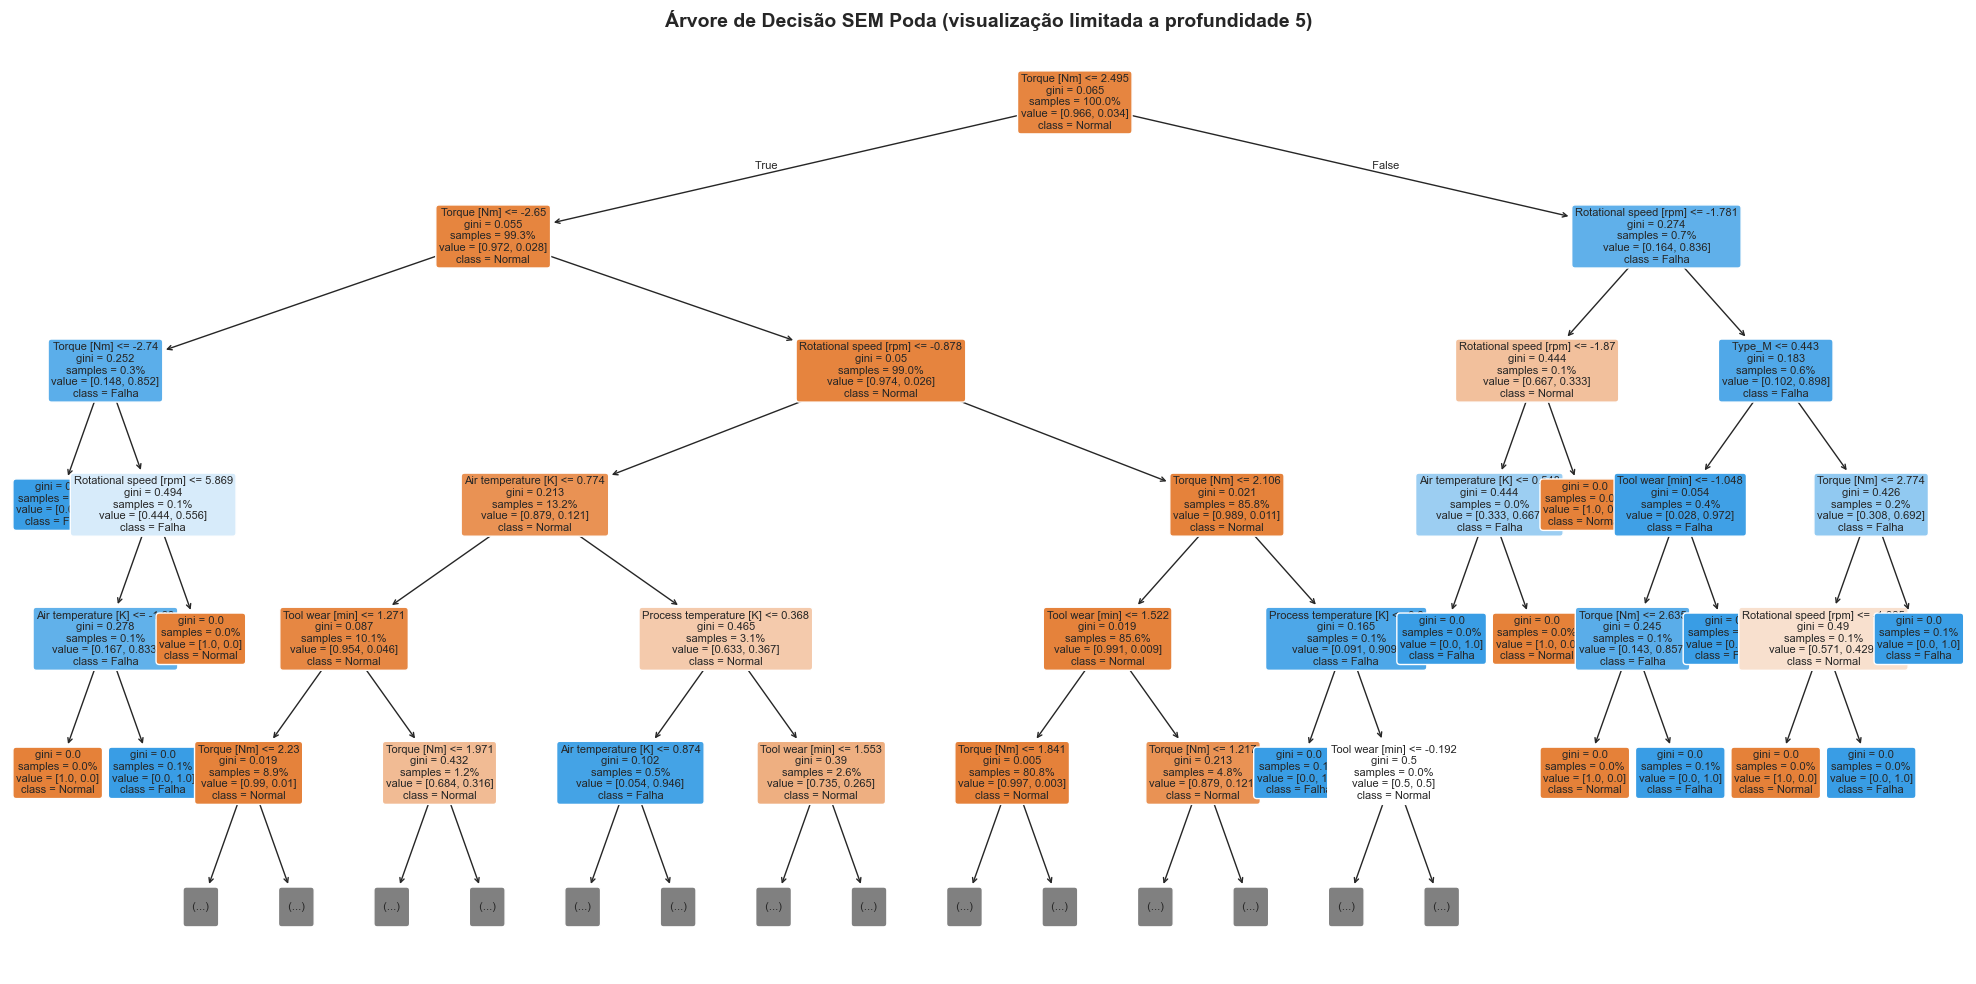

In [7]:
# Árvore sem poda
tree_full = DecisionTreeClassifier(random_state=SEED)
tree_full.fit(X_train, y_train)

print(f'Profundidade da árvore sem poda: {tree_full.get_depth()}')
print(f'Número de folhas: {tree_full.get_n_leaves()}')

# Visualização (cortada em profundidade 5 para legibilidade)
plt.figure(figsize=(20, 10))
plot_tree(tree_full, max_depth=5, feature_names=feature_names,
          class_names=['Normal', 'Falha'], filled=True, rounded=True,
          fontsize=8, proportion=True)
plt.title('Árvore de Decisão SEM Poda (visualização limitada a profundidade 5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3. Análise de Overfitting ($E_{in}$ vs $E_{out}$)

Calculamos o erro de treino ($E_{in} = 1 - \text{acurácia}_{\text{treino}}$) e o erro de teste ($E_{out} = 1 - \text{acurácia}_{\text{teste}}$) da árvore sem poda. Se $E_{in} \approx 0$ e $E_{out}$ é significativamente maior, temos evidência de overfitting: o modelo memorizou o conjunto de treino sem aprender o padrão real generalizável.


In [10]:
y_pred_train_full = tree_full.predict(X_train)
y_pred_test_full = tree_full.predict(X_test)

acc_train_full = accuracy_score(y_train, y_pred_train_full)
acc_test_full = accuracy_score(y_test, y_pred_test_full)
f2_train_full = fbeta_score(y_train, y_pred_train_full, beta=2, zero_division=0)
f2_test_full = fbeta_score(y_test, y_pred_test_full, beta=2, zero_division=0)

E_in = 1 - acc_train_full
E_out = 1 - acc_test_full

print('=== OVERFITTING: ÁRVORE SEM PODA ===')
print(f'E_in  (erro treino):  {E_in:.4f}  (Acurácia treino: {acc_train_full:.4f})')
print(f'E_out (erro teste):   {E_out:.4f}  (Acurácia teste:  {acc_test_full:.4f})')
print(f'Gap (E_out - E_in):   {E_out - E_in:.4f}')
print(f'\nF2 treino: {f2_train_full:.4f}')
print(f'F2 teste:  {f2_test_full:.4f}')

if E_in < 0.001:
    print('\nE_in ≈ 0: a árvore memorizou o conjunto de treino (overfitting evidente).')
    print('A poda é necessária para melhorar a generalização.')


=== OVERFITTING: ÁRVORE SEM PODA ===
E_in  (erro treino):  0.0000  (Acurácia treino: 1.0000)
E_out (erro teste):   0.0230  (Acurácia teste:  0.9770)
Gap (E_out - E_in):   0.0230

F2 treino: 1.0000
F2 teste:  0.6509

E_in ≈ 0: a árvore memorizou o conjunto de treino (overfitting evidente).
A poda é necessária para melhorar a generalização.


---
## 4. Poda via Minimal Cost-Complexity Pruning + Validação Cruzada

### 4.1 O Conceito de Cost-Complexity Pruning

A poda por custo-complexidade (*Minimal Cost-Complexity Pruning*) busca o equilíbrio entre a pureza da árvore e sua complexidade. Para uma sub-árvore $T$, o custo total é definido como:

$$R_\alpha(T) = R(T) + \alpha \cdot |\widetilde{T}|$$

onde:
- $R(T)$ é a impureza total (soma ponderada das impurezas de Gini em cada folha).
- $|\widetilde{T}|$ é o número de folhas terminais da sub-árvore.
- $\alpha \geq 0$ é o parâmetro de complexidade (`ccp_alpha` no scikit-learn).

Quando $\alpha = 0$, não há penalidade por complexidade e a árvore cresce ao máximo. Conforme $\alpha$ aumenta, a penalidade por cada folha extra cresce, forçando a árvore a podar ramos que não compensam a melhoria de pureza.

### 4.2 Seleção do $\alpha$ Ótimo por Validação Cruzada Estratificada

Para escolher o melhor $\alpha$, usamos validação cruzada **estratificada 5-fold** (Regra de Ouro: $K \approx N/5$), com **F2-Score** como métrica, consistente com a decisão tomada na rede neural. O `StratifiedKFold` garante que a proporção de ~3,4% de falhas seja preservada em cada fold, o que é crucial para avaliar modelos em dados desbalanceados.


In [11]:
# 4.2a Obter alphas candidatos via pruning path
ccp_alphas, impurities = obter_alphas_candidatos(X_train, y_train)
print(f'Total de alphas candidatos: {len(ccp_alphas)}')
print(f'Intervalo: [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]')


Total de alphas candidatos: 64
Intervalo: [0.000000, 0.008916]


### 4.3 Validação Cruzada para Cada $\alpha$

Testamos cada $\alpha$ candidato com e sem `class_weight='balanced'`, calculando o F2-Score médio em 5 folds estratificados.


In [12]:
# Cross-validation SEM class_weight
print('Cross-validation SEM class_weight...')
df_cv_none = cross_val_arvore(X_train, y_train, ccp_alphas, class_weight=None)

# Cross-validation COM class_weight='balanced'
print('Cross-validation COM class_weight=balanced...')
df_cv_bal = cross_val_arvore(X_train, y_train, ccp_alphas, class_weight='balanced')

# Melhor de cada cenário
best_none = df_cv_none.loc[df_cv_none['f2_mean'].idxmax()]
best_bal = df_cv_bal.loc[df_cv_bal['f2_mean'].idxmax()]

print(f'\n=== MELHOR ALPHA (sem class_weight) ===')
print(f'  alpha = {best_none["ccp_alpha"]:.6f}, F2 = {best_none["f2_mean"]:.4f} ± {best_none["f2_std"]:.4f}')
print(f'\n=== MELHOR ALPHA (com class_weight=balanced) ===')
print(f'  alpha = {best_bal["ccp_alpha"]:.6f}, F2 = {best_bal["f2_mean"]:.4f} ± {best_bal["f2_std"]:.4f}')

# Escolher o cenário vencedor
if best_bal['f2_mean'] >= best_none['f2_mean']:
    MELHOR_ALPHA = best_bal['ccp_alpha']
    MELHOR_CW = 'balanced'
    MELHOR_F2_CV = best_bal['f2_mean']
    df_cv_plot = df_cv_bal
else:
    MELHOR_ALPHA = best_none['ccp_alpha']
    MELHOR_CW = None
    MELHOR_F2_CV = best_none['f2_mean']
    df_cv_plot = df_cv_none

print(f'\n🏆 VENCEDOR: alpha={MELHOR_ALPHA:.6f}, class_weight={MELHOR_CW}, F2 CV={MELHOR_F2_CV:.4f}')


Cross-validation SEM class_weight...
Cross-validation COM class_weight=balanced...

=== MELHOR ALPHA (sem class_weight) ===
  alpha = 0.000317, F2 = 0.7010 ± 0.0674

=== MELHOR ALPHA (com class_weight=balanced) ===
  alpha = 0.000834, F2 = 0.6790 ± 0.0395

🏆 VENCEDOR: alpha=0.000317, class_weight=None, F2 CV=0.7010


### 4.4 Gráfico: $\alpha$ vs F2-Score (Validação Cruzada)


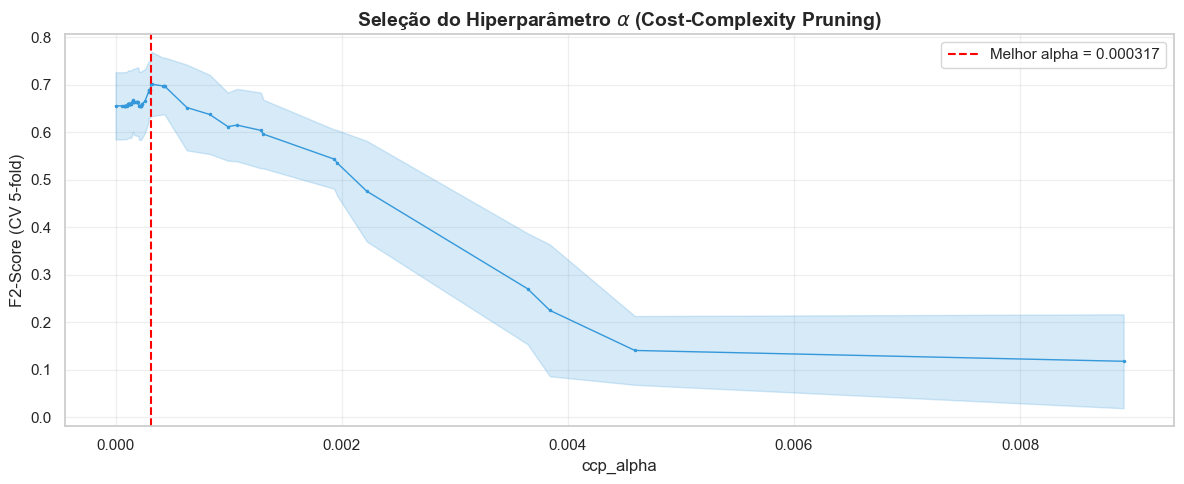

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_cv_plot['ccp_alpha'], df_cv_plot['f2_mean'], marker='.', markersize=3, color='#3498db', linewidth=1)
ax.fill_between(df_cv_plot['ccp_alpha'],
                df_cv_plot['f2_mean'] - df_cv_plot['f2_std'],
                df_cv_plot['f2_mean'] + df_cv_plot['f2_std'],
                alpha=0.2, color='#3498db')

ax.axvline(x=MELHOR_ALPHA, color='red', linestyle='--', linewidth=1.5, label=f'Melhor alpha = {MELHOR_ALPHA:.6f}')

ax.set_xlabel('ccp_alpha', fontsize=12)
ax.set_ylabel('F2-Score (CV 5-fold)', fontsize=12)
ax.set_title('Seleção do Hiperparâmetro $\\alpha$ (Cost-Complexity Pruning)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 5. Árvore Final Podada

Treinamos a árvore com o $\alpha$ ótimo encontrado e visualizamos sua estrutura. A árvore podada deve ser significativamente menor que a árvore sem poda, demonstrando que os ramos removidos eram puramente resultado de memorização do treino.


=== COMPARAÇÃO: SEM PODA vs COM PODA ===
Profundidade:  19 -> 11
Nº de folhas:  152 -> 30


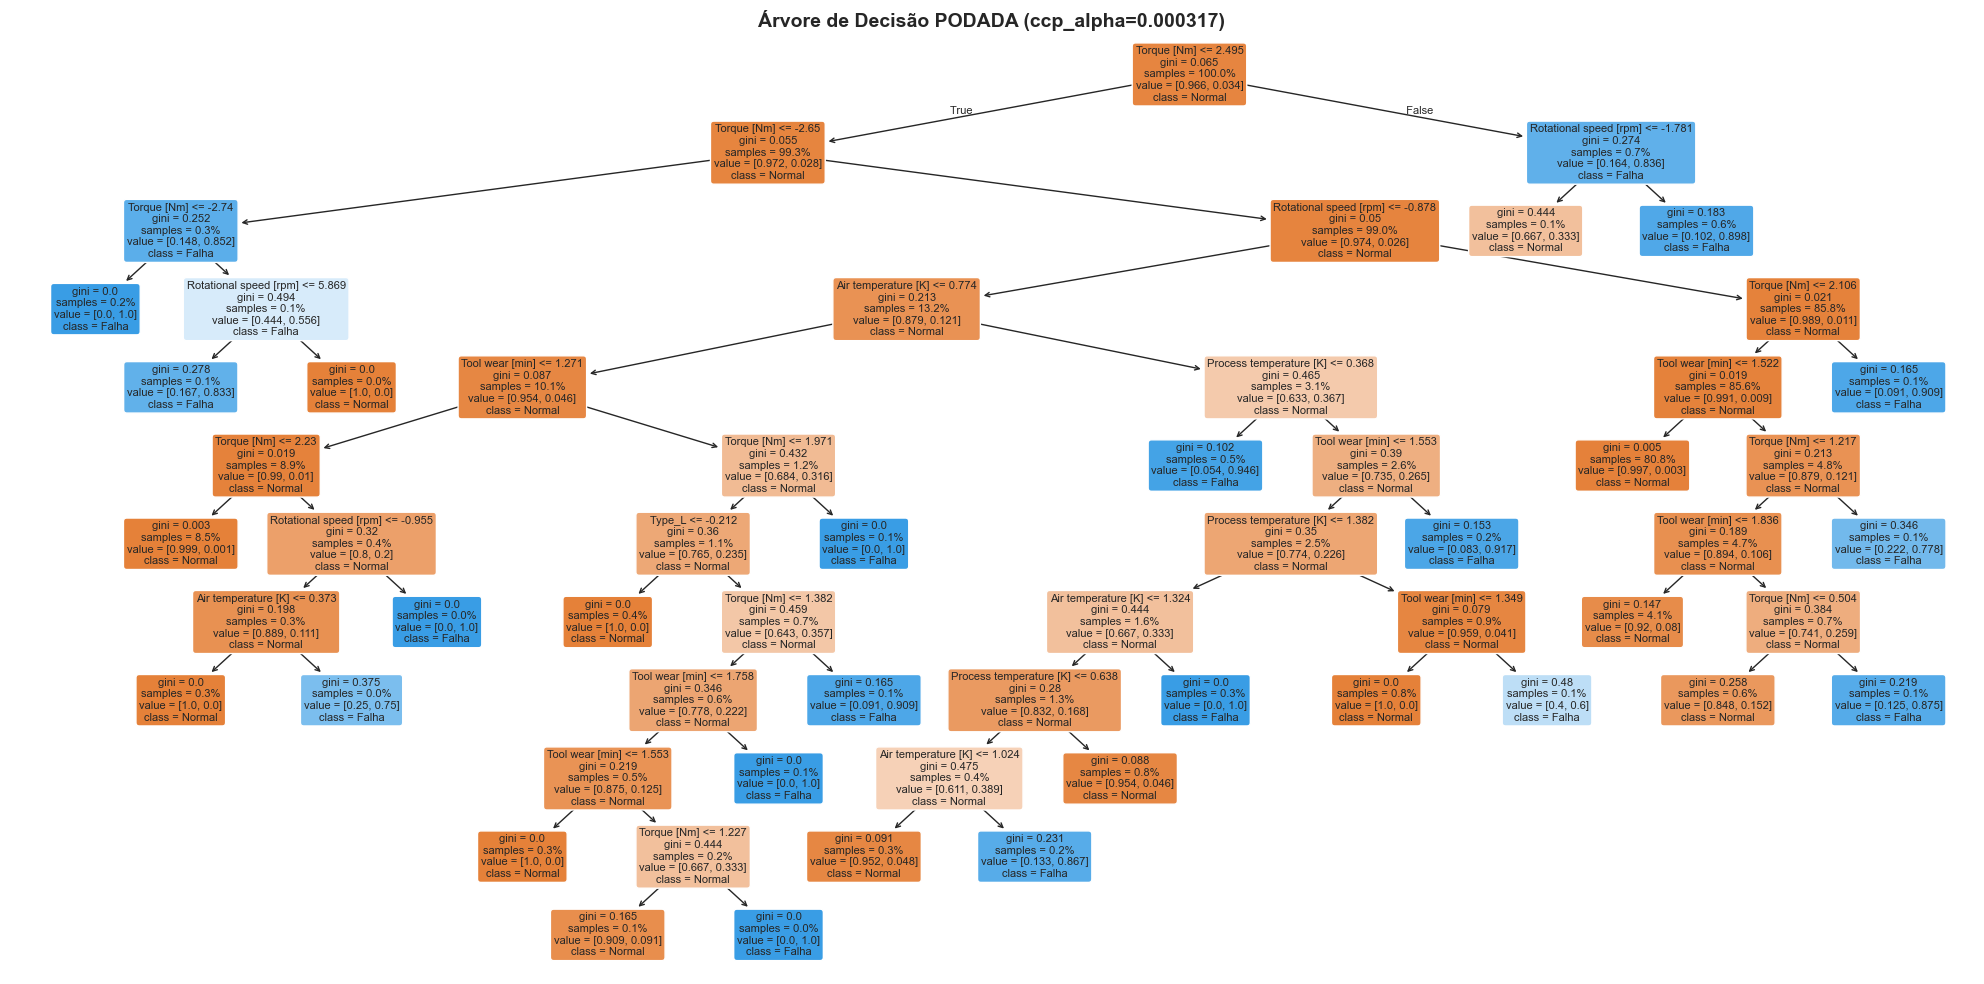

In [14]:
tree_pruned = DecisionTreeClassifier(
    ccp_alpha=MELHOR_ALPHA,
    class_weight=MELHOR_CW,
    random_state=SEED
)
tree_pruned.fit(X_train, y_train)

print(f'=== COMPARAÇÃO: SEM PODA vs COM PODA ===')
print(f'Profundidade:  {tree_full.get_depth()} -> {tree_pruned.get_depth()}')
print(f'Nº de folhas:  {tree_full.get_n_leaves()} -> {tree_pruned.get_n_leaves()}')

plt.figure(figsize=(20, 10))
plot_tree(tree_pruned, feature_names=feature_names,
          class_names=['Normal', 'Falha'], filled=True, rounded=True,
          fontsize=8, proportion=True)
plt.title(f'Árvore de Decisão PODADA (ccp_alpha={MELHOR_ALPHA:.6f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Avaliação no Conjunto de Teste (Árvore Podada)

Utilizamos o conjunto de teste para aferir a capacidade de generalização da árvore podada. Mantemos as mesmas métricas e formato do notebook da Rede Neural para facilitar a comparação posterior.


In [15]:
# Baseline
baseline_preds = np.zeros_like(y_test)
acc_baseline = accuracy_score(y_test, baseline_preds)

# Previsões da árvore podada
y_pred_tree = tree_pruned.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree, zero_division=0)
rec_tree = recall_score(y_test, y_pred_tree, zero_division=0)
f1_tree = f1_score(y_test, y_pred_tree, zero_division=0)
f2_tree = fbeta_score(y_test, y_pred_tree, beta=2, zero_division=0)

print(f'=== BASELINE ===')
print(f'Acurácia (sempre prever Normal): {acc_baseline:.4f}')

print(f'\n=== MÉTRICAS DA ÁRVORE PODADA NO TESTE ===')
print(f'Acurácia:  {acc_tree:.4f}')
print(f'Precisão:  {prec_tree:.4f} (classe 1)')
print(f'Recall:    {rec_tree:.4f} (classe 1)')
print(f'F1-Score:  {f1_tree:.4f} (classe 1)')
print(f'F2-Score:  {f2_tree:.4f} (classe 1)')

print(f'\n=== RELATÓRIO DE CLASSIFICAÇÃO ===')
print(classification_report(y_test, y_pred_tree,
      target_names=['Não Falhou (0)', 'Falhou (1)'], zero_division=0))


=== BASELINE ===
Acurácia (sempre prever Normal): 0.9660

=== MÉTRICAS DA ÁRVORE PODADA NO TESTE ===
Acurácia:  0.9855
Precisão:  0.8000 (classe 1)
Recall:    0.7647 (classe 1)
F1-Score:  0.7820 (classe 1)
F2-Score:  0.7715 (classe 1)

=== RELATÓRIO DE CLASSIFICAÇÃO ===
                precision    recall  f1-score   support

Não Falhou (0)       0.99      0.99      0.99      1932
    Falhou (1)       0.80      0.76      0.78        68

      accuracy                           0.99      2000
     macro avg       0.90      0.88      0.89      2000
  weighted avg       0.99      0.99      0.99      2000



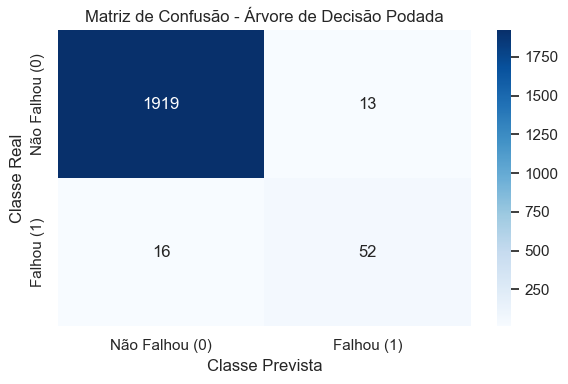

In [16]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Falhou (0)', 'Falhou (1)'],
            yticklabels=['Não Falhou (0)', 'Falhou (1)'])
plt.title('Matriz de Confusão - Árvore de Decisão Podada')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()


---
## 7. Importância das Features (Árvore de Decisão)

O atributo `feature_importances_` da árvore treinada nos mostra a contribuição relativa de cada feature para as decisões de classificação. Esperamos que **Torque** e **Tool wear** apareçam como as mais importantes, já que as regras reais de falha do dataset AI4I 2020 dependem fortemente dessas variáveis (potência mecânica e desgaste da ferramenta).


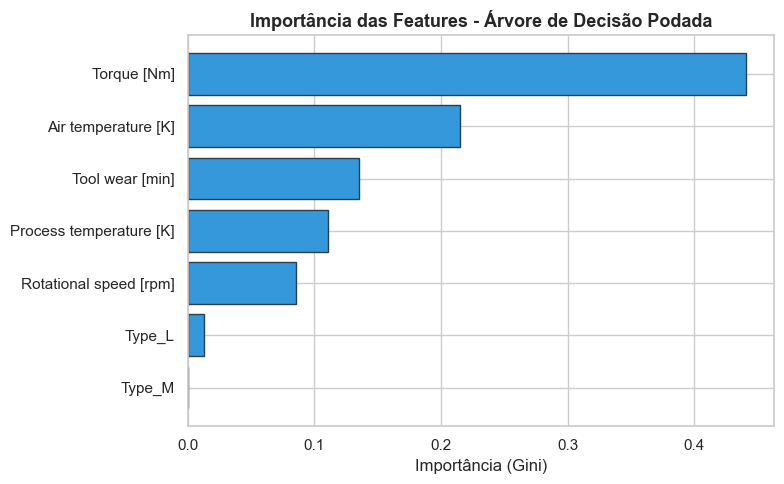


Ranking de features:
  Torque [Nm]                    0.4409
  Air temperature [K]            0.2148
  Tool wear [min]                0.1355
  Process temperature [K]        0.1107
  Rotational speed [rpm]         0.0854
  Type_L                         0.0127
  Type_M                         0.0000


In [18]:
importances_tree = tree_pruned.feature_importances_
df_imp_tree = pd.DataFrame({
    'Feature': feature_names,
    'Importância': importances_tree
}).sort_values('Importância', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(df_imp_tree['Feature'], df_imp_tree['Importância'], color='#3498db', edgecolor='#2c3e50')
plt.xlabel('Importância (Gini)')
plt.title('Importância das Features - Árvore de Decisão Podada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRanking de features:')
for _, row in df_imp_tree.sort_values('Importância', ascending=False).iterrows():
    print(f'  {row["Feature"]:30s} {row["Importância"]:.4f}')


---
# PARTE B — Random Forest 

Como extensão e para lidar melhor com o desbalanceamento de classes, também treinamos um **Random Forest** — um ensemble de múltiplas árvores de decisão. Este método tende a ser mais robusto a overfitting e pode capturar melhor padrões em dados desbalanceados, pois cada árvore do ensemble é treinada em subamostras diferentes dos dados, e a predição final é obtida por votação majoritária.


---
## 8. Grid Search do Random Forest

Testamos combinações de hiperparâmetros usando a mesma validação cruzada 5-fold estratificada e F2-Score como critério, igual à árvore individual.


In [20]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'class_weight': [None, 'balanced']
}

total_combinacoes = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['class_weight'])
print(f'Iniciando Grid Search do Random Forest ({total_combinacoes} combinações, 5-fold CV)...\n')

df_rf_grid = grid_search_random_forest(X_train, y_train, param_grid)

print(f'\n=== RESULTADO DO GRID SEARCH ===')
display(df_rf_grid)

best_rf_params = df_rf_grid.iloc[0]
BEST_N_EST = int(best_rf_params['n_estimators'])
BEST_MAX_D = int(best_rf_params['max_depth']) if best_rf_params['max_depth'] is not None and not pd.isna(best_rf_params['max_depth']) else None
BEST_CW_RF = best_rf_params['class_weight']

print(f'\n🏆 MELHOR COMBINAÇÃO:')
print(f'  n_estimators: {BEST_N_EST}')
print(f'  max_depth: {BEST_MAX_D}')
print(f'  class_weight: {BEST_CW_RF}')
print(f'  F2 CV: {best_rf_params["f2_mean"]:.4f} ± {best_rf_params["f2_std"]:.4f}')


Iniciando Grid Search do Random Forest (12 combinações, 5-fold CV)...

  [1/12] n_estimators=100, max_depth=None, class_weight=None ... F2=0.5665 ± 0.0302
  [2/12] n_estimators=100, max_depth=None, class_weight=balanced ... F2=0.4411 ± 0.0394
  [3/12] n_estimators=100, max_depth=10, class_weight=None ... F2=0.4922 ± 0.0534
  [4/12] n_estimators=100, max_depth=10, class_weight=balanced ... F2=0.5748 ± 0.0572
  [5/12] n_estimators=100, max_depth=20, class_weight=None ... F2=0.5634 ± 0.0246
  [6/12] n_estimators=100, max_depth=20, class_weight=balanced ... F2=0.4449 ± 0.0341
  [7/12] n_estimators=200, max_depth=None, class_weight=None ... F2=0.5711 ± 0.0276
  [8/12] n_estimators=200, max_depth=None, class_weight=balanced ... F2=0.4768 ± 0.0237
  [9/12] n_estimators=200, max_depth=10, class_weight=None ... F2=0.4874 ± 0.0437
  [10/12] n_estimators=200, max_depth=10, class_weight=balanced ... F2=0.5617 ± 0.0427
  [11/12] n_estimators=200, max_depth=20, class_weight=None ... F2=0.5675 ± 0.02

,n_estimators,max_depth,class_weight,f2_mean,f2_std
0,100,10.0,balanced,0.574821,0.057237
1,200,NaN,None,0.571103,0.027585
2,200,20.0,None,0.567473,0.028483
3,100,NaN,None,0.566512,0.030239
4,100,20.0,None,0.563448,0.024554
5,200,10.0,balanced,0.561744,0.042658
6,100,10.0,None,0.492169,0.053364
7,200,10.0,None,0.487415,0.043703
8,200,20.0,balanced,0.479824,0.017572
9,200,NaN,balanced,0.476845,0.023746



🏆 MELHOR COMBINAÇÃO:
  n_estimators: 100
  max_depth: 10
  class_weight: balanced
  F2 CV: 0.5748 ± 0.0572


---
## 9. Avaliação no Conjunto de Teste (Random Forest)


In [21]:
rf_final = RandomForestClassifier(
    n_estimators=BEST_N_EST,
    max_depth=BEST_MAX_D,
    class_weight=BEST_CW_RF,
    random_state=SEED,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
f2_rf = fbeta_score(y_test, y_pred_rf, beta=2, zero_division=0)

print(f'=== MÉTRICAS DO RANDOM FOREST NO TESTE ===')
print(f'Acurácia:  {acc_rf:.4f}')
print(f'Precisão:  {prec_rf:.4f} (classe 1)')
print(f'Recall:    {rec_rf:.4f} (classe 1)')
print(f'F1-Score:  {f1_rf:.4f} (classe 1)')
print(f'F2-Score:  {f2_rf:.4f} (classe 1)')

print(f'\n=== RELATÓRIO DE CLASSIFICAÇÃO ===')
print(classification_report(y_test, y_pred_rf,
      target_names=['Não Falhou (0)', 'Falhou (1)'], zero_division=0))


=== MÉTRICAS DO RANDOM FOREST NO TESTE ===
Acurácia:  0.9760
Precisão:  0.6613 (classe 1)
Recall:    0.6029 (classe 1)
F1-Score:  0.6308 (classe 1)
F2-Score:  0.6138 (classe 1)

=== RELATÓRIO DE CLASSIFICAÇÃO ===
                precision    recall  f1-score   support

Não Falhou (0)       0.99      0.99      0.99      1932
    Falhou (1)       0.66      0.60      0.63        68

      accuracy                           0.98      2000
     macro avg       0.82      0.80      0.81      2000
  weighted avg       0.98      0.98      0.98      2000



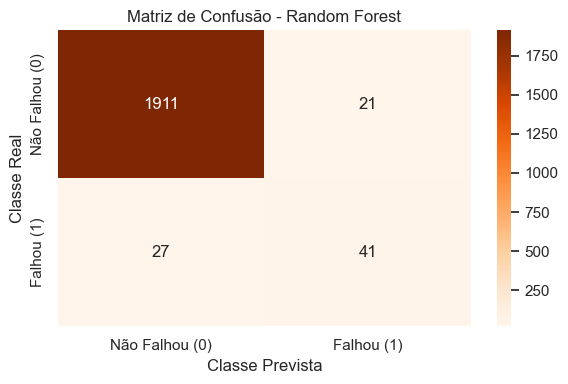

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Não Falhou (0)', 'Falhou (1)'],
            yticklabels=['Não Falhou (0)', 'Falhou (1)'])
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()


---
## 10. Importância das Features (Random Forest)

A importância de features calculada pelo Random Forest tende a ser mais estável e confiável que a de uma única árvore, pois é a média ponderada das importâncias de todas as árvores do ensemble.


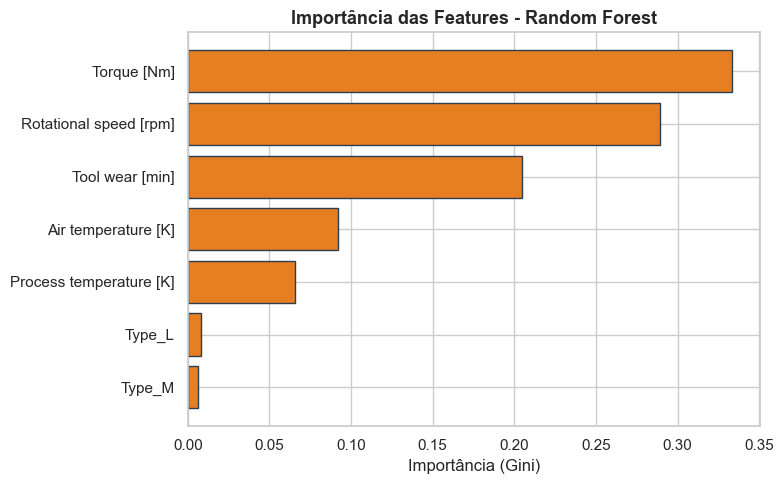


Ranking de features (Random Forest):
  Torque [Nm]                    0.3337
  Rotational speed [rpm]         0.2893
  Tool wear [min]                0.2050
  Air temperature [K]            0.0920
  Process temperature [K]        0.0658
  Type_L                         0.0080
  Type_M                         0.0063


In [23]:
importances_rf = rf_final.feature_importances_
df_imp_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importância': importances_rf
}).sort_values('Importância', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(df_imp_rf['Feature'], df_imp_rf['Importância'], color='#e67e22', edgecolor='#2c3e50')
plt.xlabel('Importância (Gini)')
plt.title('Importância das Features - Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRanking de features (Random Forest):')
for _, row in df_imp_rf.sort_values('Importância', ascending=False).iterrows():
    print(f'  {row["Feature"]:30s} {row["Importância"]:.4f}')


---
## 11. Comparação: Árvore de Decisão Podada vs Random Forest


In [24]:
df_comp = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão (Classe 1)', 'Recall (Classe 1)', 'F1-Score (Classe 1)', 'F2-Score (Classe 1)'],
    'Árvore Podada': [acc_tree, prec_tree, rec_tree, f1_tree, f2_tree],
    'Random Forest': [acc_rf, prec_rf, rec_rf, f1_rf, f2_rf],
    'Baseline': [acc_baseline, 0.0, 0.0, 0.0, 0.0]
})

print('=== COMPARAÇÃO LADO A LADO ===')
display(df_comp)

# Identificar vencedor pelo F2-Score
if f2_rf > f2_tree:
    print(f'\n🏆 O Random Forest venceu pelo F2-Score ({f2_rf:.4f} vs {f2_tree:.4f}).')
elif f2_tree > f2_rf:
    print(f'\n🏆 A Árvore Podada venceu pelo F2-Score ({f2_tree:.4f} vs {f2_rf:.4f}).')
else:
    print(f'\n🤝 Empate no F2-Score ({f2_tree:.4f}).')


=== COMPARAÇÃO LADO A LADO ===


,Métrica,Árvore Podada,Random Forest,Baseline
0,Acurácia,0.985500,0.976000,0.966
1,Precisão (Classe 1),0.800000,0.661290,0.000
2,Recall (Classe 1),0.764706,0.602941,0.000
3,F1-Score (Classe 1),0.781955,0.630769,0.000
4,F2-Score (Classe 1),0.771513,0.613772,0.000



🏆 A Árvore Podada venceu pelo F2-Score (0.7715 vs 0.6138).


---
## 12. Salvamento dos Modelos


In [25]:
path_tree = os.path.join(MODELOS_DIR, 'arvore_decisao.pkl')
path_rf = os.path.join(MODELOS_DIR, 'random_forest.pkl')

joblib.dump(tree_pruned, path_tree)
joblib.dump(rf_final, path_rf)

print(f'Árvore de Decisão salva em: {path_tree}')
print(f'Random Forest salvo em: {path_rf}')


Árvore de Decisão salva em: /Users/anne/Documents/UFPB/manutencao-preditiva/modelos/arvore_decisao.pkl
Random Forest salvo em: /Users/anne/Documents/UFPB/manutencao-preditiva/modelos/random_forest.pkl


---
## 13. Resumo Final


In [26]:
print('=' * 70)
print('RESUMO FINAL — MODELOS BASEADOS EM ÁRVORES')
print('=' * 70)

print('\n--- Árvore de Decisão (resultado oficial) ---')
print(f'  Poda: Cost-Complexity com alpha = {MELHOR_ALPHA:.6f}')
print(f'  class_weight: {MELHOR_CW}')
print(f'  Profundidade final: {tree_pruned.get_depth()}')
print(f'  Folhas: {tree_pruned.get_n_leaves()}')
print(f'  Acurácia:  {acc_tree:.4f} (vs baseline: {acc_baseline:.4f})')
print(f'  F1-Score:  {f1_tree:.4f}')
print(f'  F2-Score:  {f2_tree:.4f}')
print(f'  Recall:    {rec_tree:.4f}')
print(f'  Precisão:  {prec_tree:.4f}')

print('\n--- Random Forest (extensão) ---')
print(f'  n_estimators: {BEST_N_EST}')
print(f'  max_depth: {BEST_MAX_D}')
print(f'  class_weight: {BEST_CW_RF}')
print(f'  Acurácia:  {acc_rf:.4f}')
print(f'  F1-Score:  {f1_rf:.4f}')
print(f'  F2-Score:  {f2_rf:.4f}')
print(f'  Recall:    {rec_rf:.4f}')
print(f'  Precisão:  {prec_rf:.4f}')

print('\n' + '=' * 70)


RESUMO FINAL — MODELOS BASEADOS EM ÁRVORES

--- Árvore de Decisão (resultado oficial) ---
  Poda: Cost-Complexity com alpha = 0.000317
  class_weight: None
  Profundidade final: 11
  Folhas: 30
  Acurácia:  0.9855 (vs baseline: 0.9660)
  F1-Score:  0.7820
  F2-Score:  0.7715
  Recall:    0.7647
  Precisão:  0.8000

--- Random Forest (extensão) ---
  n_estimators: 100
  max_depth: 10
  class_weight: balanced
  Acurácia:  0.9760
  F1-Score:  0.6308
  F2-Score:  0.6138
  Recall:    0.6029
  Precisão:  0.6613

